# WSDM-KKBOX Music Recommendation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Loading the datasets
train_url = "https://confrecordings.ams3.digitaloceanspaces.com/train_1_5104.csv"
songs_url = "https://confrecordings.ams3.digitaloceanspaces.com/songs_1_813.csv"

train = pd.read_csv(train_url)
songs = pd.read_csv(songs_url)

# Inspection
datasets = {'Train': train, 'Songs': songs}

for name, df in datasets.items():
    print(f"--- {name} Dataset Inspection ---")
    print(f"Top 5 rows:\n{df.head()}\n")
    print(f"Null values:\n{df.isnull().sum()}\n")
    print(f"Info:")
    df.info()
    print(f"Shape: {df.shape}\n")
    print("-" * 30)

--- Train Dataset Inspection ---
Top 5 rows:
                                           msno  \
0  FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=   
1  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
2  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
3  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
4  FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=   

                                        song_id source_system_tab  \
0  BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=           explore   
1  bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=        my library   
2  JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=        my library   
3  2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=        my library   
4  3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=           explore   

    source_screen_name      source_type  target  
0              Explore  online-playlist       1  
1  Local playlist more   local-playlist       1  
2  Local playlist more   local-playlist       1  
3  Local playlist more   local-pl

In [4]:
# How many times user listens to the song again (Target Distribution)
v = train['target'].value_counts()
listen_again_pct = (v * 100 / v.sum())
print(f"Listen Again Percentage:\n{listen_again_pct}\n")

# Unique songs in train dataset
unique_songs = train['song_id'].nunique()
print(f"Number of unique songs: {unique_songs}\n")

Listen Again Percentage:
target
1    75.633513
0    24.366487
Name: count, dtype: float64

Number of unique songs: 18392



In [5]:
# Create repeat dataframe (target == 1)
repeat = train[train['target'] == 1]

# Count repeats per song_id
song_repeats = repeat.groupby('song_id').size().reset_index()
song_repeats.columns = ['song_id', 'count']

In [6]:
# Merge song details with repeat counts
song_repeats = pd.merge(songs, song_repeats, on='song_id')

print("--- Merged Song Repeats (Top 5) ---")
print(song_repeats.head())
print(f"\nMissing values in merged data:\n{song_repeats.isnull().sum()}")
print(f"\nDatatypes:\n{song_repeats.dtypes}\n")

--- Merged Song Repeats (Top 5) ---
                                        song_id  song_length genre_ids  \
0  o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=       197328       444   
1  dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=       273554       465   
2  W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=       140329       726   
3  N9vbanw7BSMoUgdfJlgX1aZPE1XZg8OS1wf88AQEcMc=       226220       458   
4  oTi7oINPX+rxoGp+3O6llSltQTl80jDqHoULfRoLcG4=       228623       465   

       artist_name                            composer      lyricist  \
0        BLACKPINK  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM         TEDDY   
1            S.H.E                                 湯小康           徐世珍   
2             貴族精選                         Traditional   Traditional   
3  伍佰 & China Blue                        Jonathan Lee           NaN   
4     林俊傑 (JJ Lin)                              JJ Lin  Wu Qing Feng   

   language  count  
0        31     50  
1         3      1  
2        52      1  
3 

Top 5 Artists from List: ['周湯豪 (NICKTHEREAL)', '五月天 (Mayday)', 'The Chainsmokers', 'G.E.M.鄧紫棋', '林芯儀 (Shennio Lin)']

Plotting Language Distribution...


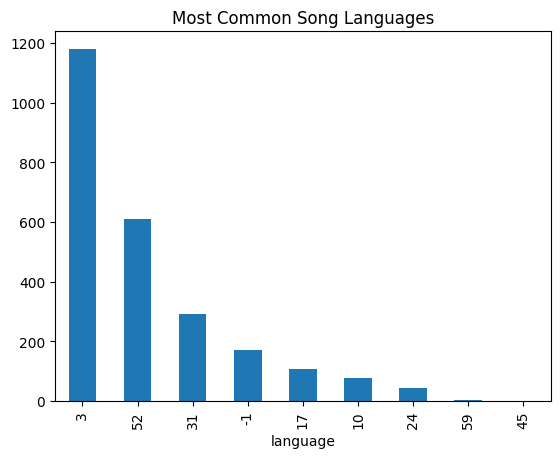

Top 10 Composers:
composer
unknown    804
周杰倫         42
阿信          17
林俊傑         14
李宗盛         10
吳克群         10
蔡健雅          9
張簡君偉         9
徐佳瑩          8
王力宏          7
Name: count, dtype: int64

Top 10 Lyricists:
lyricist
unknown    1292
方文山          25
阿信           25
姚若龍          15
李宗盛          11
黃婷           11
葛大為          10
林夕            9
吳克群           9
蔡健雅           8
Name: count, dtype: int64

Top 20 Users (by repeats):
msno
EozJegFxTFIWDb9aJ7O8kSUHAgx4ZIvqf7IuN5Zck50=    237
V5U4EGk2kaSKaUGSwhU6g3HBefxflEvAy1vWPu6UBQs=    196
p56/iJa3NyqT0XayXDQhMVLqRF532rLyuyksGdsmwkE=    179
W9NYSCff57nmfyYCiX6IbW0/G3YuwC18h/rld+BGxMY=    152
KRMGuUAJmY6wHmXjvJSYiIKht24aWw9tKPgcQbufhic=    122
UbgsoK9XaLGGeXKb/GdnyVpt2TMk9nusXuOnRv+jCEg=    122
wv0o115CdKSsFlsV7VvHikjyxLG0LFc5qALhM8xkUZ4=    115
4tNLa7RUIKfmX0HHm0Bh0kuG864GH9DXpTZqLFS9Y0Y=    105
Bwg9yS76qujJJeKsYSzfJrMlkjK5Ui7KFkgUcjuXRCg=     90
H54yhciGEPT4YEfeF80FJscg0nvDifqIIDPLhyY2Lvs=     87
Wr1nXgbn/woZvQ6Ndcff9w9baMhO2h

In [7]:
# Replace NA in object columns with 'unknown'
for i in song_repeats.select_dtypes(include=['object']).columns:
    song_repeats.loc[song_repeats[i].isnull(), i] = 'unknown'

# Fill remaining NA (numeric) with 0
song_repeats = song_repeats.fillna(value=0)

# 1. Most common song artists (Top 100)
top_100_artists = song_repeats.sort_values(by='count', ascending=False)[:100]['artist_name'].tolist()
print(f"Top 5 Artists from List: {top_100_artists[:5]}\n")

# 2. Most common song languages (Sorted by count and plotted)
print("Plotting Language Distribution...")
song_repeats.sort_values(by='count', ascending=False)['language'].value_counts().plot(kind="bar")
plt.title("Most Common Song Languages")
plt.show()

# 3. Most common composer
top_composers = song_repeats.sort_values(by='count', ascending=False)['composer'].value_counts().head(10)
print(f"Top 10 Composers:\n{top_composers}\n")

# 4. Most common lyricist
top_lyricists = song_repeats.sort_values(by='count', ascending=False)['lyricist'].value_counts().head(10)
print(f"Top 10 Lyricists:\n{top_lyricists}\n")

# 5. Top 20 Users who listen to the same song again
top_20_users = repeat['msno'].value_counts().head(20)
print(f"Top 20 Users (by repeats):\n{top_20_users}")

# Spotify Music Recommendation

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/top50.csv', encoding='latin-1')

print("--- Top 5 Rows ---")
print(data.head())
print("\n--- Column Names ---")
print(data.columns)
print("\n--- Null Values ---")
print(data.isnull().sum())
print("\n--- Info ---")
data.info()
print("\n--- Shape ---")
print(data.shape)

--- Top 5 Rows ---
   Unnamed: 0                       Track.Name    Artist.Name           Genre  \
0           1                         Señorita   Shawn Mendes    canadian pop   
1           2                            China       Anuel AA  reggaeton flow   
2           3    boyfriend (with Social House)  Ariana Grande       dance pop   
3           4  Beautiful People (feat. Khalid)     Ed Sheeran             pop   
4           5      Goodbyes (Feat. Young Thug)    Post Malone         dfw rap   

   Beats.Per.Minute  Energy  Danceability  Loudness..dB..  Liveness  Valence.  \
0               117      55            76              -6         8        75   
1               105      81            79              -4         8        61   
2               190      80            40              -4        16        70   
3                93      65            64              -8         8        55   
4               150      65            58              -4        11        18   

   Leng

In [10]:
print("\n" + "="*30 + " RECOMMENDATIONS " + "="*30)


============================== RECOMMENDATIONS ==============================


In [11]:
# 1. Artist Name with highest popularity
highest_pop_artist = data.loc[data['Popularity'].idxmax(), 'Artist.Name']
print(f"Artist with highest popularity: {highest_pop_artist}")

Artist with highest popularity: Billie Eilish


In [12]:
# 2. Artist Name which is Most Popular (Frequency/Count)
most_popular_artist = data['Artist.Name'].value_counts().idxmax()
print(f"Most Popular Artist (Frequency): {most_popular_artist}")

Most Popular Artist (Frequency): Ed Sheeran


In [13]:
# 3. Artist Name with highest Energy
highest_energy_artist = data.loc[data['Energy'].idxmax(), 'Artist.Name']
print(f"Artist with highest Energy: {highest_energy_artist}")

Artist with highest Energy: Katy Perry


In [14]:
# 4. Artist Name with highest Beats Per Minute
highest_bpm_artist = data.loc[data['Beats.Per.Minute'].idxmax(), 'Artist.Name']
print(f"Artist with highest BPM: {highest_bpm_artist}")

Artist with highest BPM: Ariana Grande


In [15]:
# 5. Artist Name with highest Liveness
highest_liveness_artist = data.loc[data['Liveness'].idxmax(), 'Artist.Name']
print(f"Artist with highest Liveness: {highest_liveness_artist}")

Artist with highest Liveness: Marshmello


In [16]:
# 6. Genre with highest count
top_genre = data['Genre'].value_counts().idxmax()
print(f"Genre with highest count: {top_genre}")

Genre with highest count: dance pop


In [17]:
# 7. Top 10 artists with top genres (based on popularity)
top_10_art_gen = data.sort_values(by='Popularity', ascending=False)[['Artist.Name', 'Genre']].head(10)
print("\nTop 10 Artists and their Genres:\n", top_10_art_gen)


Top 10 Artists and their Genres:
       Artist.Name             Genre
9   Billie Eilish        electropop
4     Post Malone           dfw rap
10      Bad Bunny         reggaeton
1        Anuel AA    reggaeton flow
14          Drake  canadian hip hop
6       Lil Tecca        trap music
17    Post Malone           dfw rap
21      Lil Nas X       country rap
20         MEDUZA         pop house
19          Lizzo       escape room


In [18]:
# 8. Genre with highest popularity (average)
highest_pop_genre = data.groupby('Genre')['Popularity'].mean().idxmax()
print(f"\nGenre with highest average popularity: {highest_pop_genre}")


Genre with highest average popularity: dfw rap


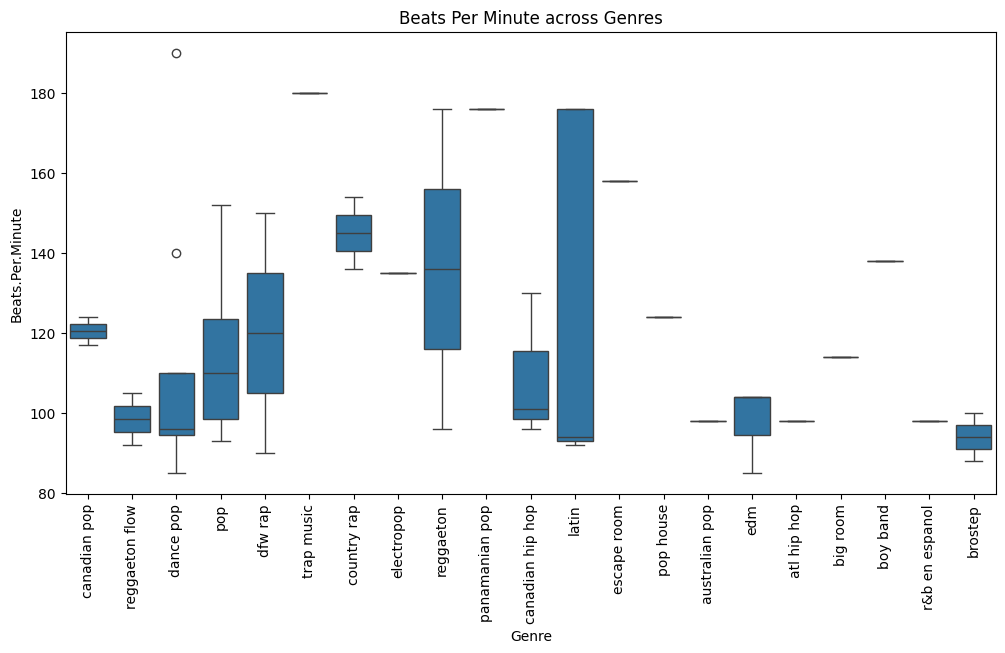

In [19]:
# 9. Visualise Beats.Per.Minute for different Genres
plt.figure(figsize=(12,6))
sns.boxplot(x='Genre', y='Beats.Per.Minute', data=data)
plt.xticks(rotation=90)
plt.title('Beats Per Minute across Genres')
plt.show()

In [20]:
# 10. Genre with highest Energy
highest_energy_genre = data.groupby('Genre')['Energy'].mean().idxmax()
print(f"Genre with highest Energy: {highest_energy_genre}")

Genre with highest Energy: reggaeton flow


In [21]:
# 11. Genre with highest Liveness
highest_liveness_genre = data.groupby('Genre')['Liveness'].mean().idxmax()
print(f"Genre with highest Liveness: {highest_liveness_genre}")

Genre with highest Liveness: brostep


In [22]:
# 12. Genre most suitable for dancing (Danceability)
dance_genre = data.groupby('Genre')['Danceability'].mean().idxmax()
print(f"Genre most suitable for dancing: {dance_genre}")

Genre most suitable for dancing: r&b en espanol


In [23]:
# 13. Artist with highest Danceability
highest_dance_artist = data.loc[data['Danceability'].idxmax(), 'Artist.Name']
print(f"Artist with highest Danceability: {highest_dance_artist}")

Artist with highest Danceability: Khalid


In [24]:
# 14. Artist with highest duration of song
longest_song_artist = data.loc[data['Length.'].idxmax(), 'Artist.Name']
print(f"Artist with highest song duration: {longest_song_artist}")

Artist with highest song duration: Jhay Cortez
